![logo](https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials/blob/main/docs/source/_figures/Helmholtz-AI.png?raw=true)

# Model-Agnostic Interpretation with SHAP

In this Notebook, we will demonstrate how to use the SHapley Additive exPlanations (SHAP) method and interpret its results.

--------

## Getting Started

### Setup Colab environment

If you installed the packages and requirements on your machine, you can skip this section and start from the import section.
Otherwise, you can follow and execute the tutorial on your browser. To start working on the notebook, click on the following button. This will open this page in the Colab environment, and you will be able to execute the code on your own.

<a href="https://colab.research.google.com/github/HelmholtzAI-Consultants-Munich/XAI-Tutorials/blob/main/xai-for-random-forest/Gen-3-Tutorial_SHAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Now that you opened the notebook in Google Colab, follow the next step:

1. Run this cell to connect your Google Drive to Colab and install packages
2. Allow this notebook to access your Google Drive files. Click on 'Yes', and select your account.
3. "Google Drive for desktop wants to access your Google Account". Click on 'Allow'.
   
At this point, a folder has been created in your Drive, and you can navigate it through the lefthand panel in Colab. You might also have received an email that informs you about the access on your Google Drive.

In [ ]:
# Mount drive folder to dbe abale to download repo
# from google.colab import drive
# drive.mount('/content/drive')

# Switch to correct folder'
# %cd /content/drive/MyDrive

In [ ]:
# Don't run this cell if you already cloned the repo 
# %rm -r XAI-Tutorials
# !git clone --branch main https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials.git

In [ ]:
# Install al required dependencies and package versions
# %cd XAI-Tutorials
# !pip install -r requirements_xai-for-random-forest.txt
# %cd xai-for-random-forest

### Imports

Let's start with importing all required Python packages.

In [1]:
import sys
import pickle

import time
import numpy as np
import pandas as pd

import shap

sys.path.append('./')
import utils

Now, we fix the random seeds to ensure reproducible results, as we work with (pseudo) random numbers.

In [2]:
# assert reproducible random number generation
seed = 1
np.random.seed(seed)

--------

## Data and Model Loading: The California Housing Dataset

In this notebook, we will work with the **California Housing dataset**, containing 20,640 median house values for California districts (expressed in $100,000), which are described by 8 numeric feature. Each row in the dataset represents a block of houses, not a single household. The data pertains to the house prices found in a given California district and some summary statistics about them based on the 1990 census data. Our goal is to **predict price** of house blocks and find the most predictive features.

<center><img src="https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials/blob/main/docs/source/_figures/dataset_california_housing.jpg?raw=true" width="900" /></center>

<font size=1> Source: [Link](https://www.kaggle.com/datasets/harrywang/housing)

In the notebook [*Gen-0-Tutorial_RandomForest_Model_Housing_Wine_Penguins.ipynb*](./Gen-0-Tutorial_RandomForest_Model_Housing_Wine_Penguins.ipynb), we explain how to do the exploratory data analysis, preprocess the data and train a Random Forest model with the given data. The focus of this notebook is the interpretation of the previously trained model.

In [3]:
# Load and unpack the data
with open('../models/model_rf_housing.pickle', 'rb') as handle:
    data_and_model = pickle.load(handle)

X_train, X_test, y_train, y_test, model_housing, scaler = data_and_model

print(f'Model Performance on training data: {round(model_housing.score(X_train, y_train),2)} R^2.')
print(f'Model Performance on test data: {round(model_housing.score(X_test, y_test),2)} R^2.')

Model Performance on training data: 0.84 R^2.
Model Performance on test data: 0.72 R^2.


As we can see by the numbers above, our model performs well on the training set and also generalizes well to the independent test set.

**You should keep in mind that interpreting a low-performing model can lead to wrong conclusions.**

*Note: The $R^2$ is the coefficient of determination, and the closer this value is to 1, the better our model explains the data. A constant model that always predicts the average target value disregarding the input features would get an $R^2$ score of 0. However, the $R^2$ score can also be negative because the model can be arbitrarily worse.*

## Now, what does my model think is important in the data?

### SHapley Additive exPlanations (SHAP)

**Before starting with the practical example, watch our [video introduction to SHAP](https://xai-tutorials.readthedocs.io/en/latest/_model_agnostic_xai/shap.html#video-introduction) to understand the general idea behind Shapley-based feature attribution.**

Since we are working with tabular data in this notebook, also have a look at the [SHAP for Tabular Data](https://xai-tutorials.readthedocs.io/en/latest/_model_agnostic_xai/shap.html#shap-for-tabular-data) section to understand how features, missingness, and the baseline are defined for tabular inputs.

*Note: All references can be found [here](https://xai-tutorials.readthedocs.io/en/latest/_model_agnostic_xai/shap.html#references).*

<font color='green'>

#### Question 1: What does a SHAP value tell you about the contribution of a feature to an individual prediction?

<font color='grey'>

#### Your Answer:

* A SHAP value describes how much a feature contributes to moving the model output from the baseline toward the prediction for the individual instance.

* A positive SHAP value contributes toward increasing the model output relative to the baseline, while a negative SHAP value contributes toward decreasing it. The magnitude indicates the strength of the contribution.

<font color='green'>

<font color='green'>

#### Question 2: When SHAP evaluates a coalition of tabular features, what happens to features that are not part of the coalition?

<font color='grey'>

#### Your Answer:

* The model still requires a complete input, so features outside the coalition cannot simply be removed.

* In the background-based formulation used here, their values are replaced using values from background samples. The model is evaluated for these completed inputs, and the predictions are averaged to obtain the value of the coalition.

<font color='green'>

#### Question 3: What does the SHAP baseline represent for the background-based tabular formulation?

<font color='grey'>

#### Your Answer:

* The baseline is the model output associated with the empty feature coalition, where none of the feature values from the instance being explained are available.

* For the background-based tabular formulation, this corresponds to the average model prediction over the background data.

<font color='green'>

#### Question 4: Why can correlated features make SHAP explanations for tabular data more difficult to interpret?

<font color='grey'>

#### Your Answer:

* When a feature is treated as missing and replaced with values from the background data, relationships between correlated features may be broken.

* This can create unrealistic feature combinations and cause the model to be evaluated outside the typical data distribution. In addition, correlated features can contain overlapping information, so their contributions may be distributed across several features.

### SHAP Explainers

So far, we have learned **what SHAP values represent**: feature contributions that explain the difference between a baseline and an individual prediction.

However, SHAP itself is an **attribution framework, not a single algorithm**. Computing SHAP values requires evaluating the underlying Shapley attribution game, which can become computationally expensive because the number of possible feature coalitions grows exponentially with the number of features.

Different **SHAP explainers** use different strategies to make this computation feasible. Some explainers are **model-agnostic** and treat the model as a black box, while others are **model-specific** and exploit the internal structure of particular model types to compute SHAP values more efficiently. Model-agnostic explainers only require access to the model's inputs and predictions and can therefore be applied to essentially any model. 

Two important model-agnostic SHAP explainers are **KernelExplainer** and **PartitionExplainer**. Both can be applied independently of the model type but use different strategies to make the SHAP computation feasible. For tabular data, we focus on KernelExplainer as our model-agnostic reference. PartitionExplainer is particularly useful for structured inputs and will be introduced in more detail in the image and text tutorials.

*For further details, see the [SHAP Explainer API](https://shap.readthedocs.io/en/latest/api.html#explainers) and [Lundberg et al. (2020)](https://doi.org/10.1038/s42256-019-0138-9).*

#### KernelExplainer

**KernelExplainer (KernelSHAP)** is a model-agnostic method that approximates SHAP values by evaluating only a **selected sample of feature coalitions** instead of all $2^M$ possible coalitions. It then uses these coalition values together with special **SHAP weights** to estimate the feature contributions.

KernelSHAP therefore makes the general Shapley calculation feasible by **carefully selecting and weighting coalitions instead of evaluating the complete coalition space**. Since it treats the model as a black box, it can be applied to essentially any model for which predictions can be obtained.

<details>
<summary><b>Optional: How does KernelSHAP work?</b></summary>

<br>

**KernelExplainer** is a model-agnostic method that approximates SHAP values by evaluating a sample of feature coalitions rather than all $2^M$ possible coalitions.

Each sampled coalition is represented by a **binary mask**, where 1 means that a feature is present in the coalition and 0 means that it is treated as missing. For example, for three features $A$, $B$, and $C$, the coalition $\{A,B\}$ is represented as $(1,1,0)$. For each sampled coalition, KernelExplainer evaluates the original model to obtain its **coalition value** $v_x(S)$. This creates a new dataset in which the binary coalition masks are the inputs and the corresponding coalition values are the targets. In addition, each coalition receives a **SHAP kernel weight** $\pi(S)$ that determines how strongly this coalition influences the subsequent regression. A simplified dataset could therefore look like this:

| $z_A$ | $z_B$ | $z_C$ | Target | Weight |
| ----: | ----: | ----: | ----: | ----: |
| 0 | 0 | 0 | $v_x(\emptyset)$ | special case |
| 1 | 0 | 0 | $v_x(\{A\})$ | $\pi(\{A\})$ |
| 0 | 1 | 0 | $v_x(\{B\})$ | $\pi(\{B\})$ |
| 1 | 1 | 0 | $v_x(\{A,B\})$ | $\pi(\{A,B\})$ |
| 0 | 1 | 1 | $v_x(\{B,C\})$ | $\pi(\{B,C\})$ |
| 1 | 1 | 1 | $v_x(\{A,B,C\})$ | special case |

KernelExplainer then fits an **additive linear model** to these coalition values:

$$
g(z)=\phi_0+\phi_A z_A+\phi_B z_B+\phi_C z_C
$$

Here, $z_i$ indicates whether feature $i$ is present in the coalition. The coefficient $\phi_i$ will become the estimated SHAP value of feature $i$. The important part is **how this linear model is fitted**. KernelExplainer does not treat every evaluated coalition equally. Instead, it minimizes a **weighted regression error**:

$$
\min_{\phi}\sum_S\pi(S)\left[v_x(S)-g(z_S)\right]^2
$$

The SHAP kernel weight $\pi(S)$ therefore controls **how strongly the error for coalition $S$ influences the fitted coefficients**. A coalition with a larger weight has a stronger influence on the regression solution than a coalition with a smaller weight. For a coalition $S$ with $|S|$ present features out of $M$ total features, the SHAP kernel weight is 

$$
\pi(S)=\frac{M-1}{\binom{M}{|S|}\,|S|\,(M-|S|)}
$$

The weighting gives greater importance to very small and very large coalitions, while the empty and full coalitions are handled specially so that the explanation is anchored at the baseline and the prediction: $g(0,\ldots,0)=v_x(\emptyset)$ and $g(1,\ldots,1)=f(x)$. The **SHAP kernel weights connect the linear regression back to the coalition weights in the original Shapley-value calculation**. With many features, the number of possible coalitions is very uneven across coalition sizes. There are only a few very small and very large coalitions, but many more medium-sized coalitions. For example, with 10 features, there are only 10 coalitions containing one feature, but 252 coalitions containing five features. If every coalition were treated equally in the regression, the medium-sized coalitions could dominate simply because there are many more of them. The SHAP kernel weights correct for this combinatorial imbalance: rarer, very small and very large coalitions receive more weight, while the numerous medium-sized coalitions receive less weight. In this way, the weighted regression reflects the coalition weighting required by the original Shapley-value calculation rather than being dominated by the most common coalition sizes. This allows the fitted coefficients $\phi_i$ to estimate the SHAP values.

KernelExplainer can therefore approximate SHAP values without explicitly evaluating every possible coalition. However, it still requires repeated evaluations of the original model and can become computationally expensive when the number of features is large.

<p align="center">
  <img src="https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials/blob/main/docs/source/_figures/shap_kernelshap_overview.png?raw=true" width="95%">
</p>

<p align="center">
  <em>Overview of KernelSHAP. KernelSHAP samples feature coalitions, evaluates their model outputs, and uses SHAP kernel weights in a weighted linear model to estimate the SHAP values.</em>
</p>

</details>

#### TreeExplainer

Since the model in this notebook is a **Random Forest**, we can use a more efficient, model-specific approach instead of treating the model as a black box.

`shap.TreeExplainer` implements **TreeSHAP**, an algorithm specifically designed for tree-based models. TreeSHAP still accounts for the different feature-coalition required by the Shapley calculation, but it does **not explicitly construct and evaluate every coalition separately**. Instead, TreeSHAP exploits the known **structure of the decision trees**. While traversing a tree, it uses **dynamic programming** to keep track of many cases in which features are present or missing at the same time. When a leaf is reached, this information is used to calculate the corresponding Shapley-weighted feature contributions TreeExplainer simply provides a much more efficient way to compute these contributions for tree-based models.

<details>
<summary><b>Optional: How does TreeSHAP work?</b></summary>

<br>

**TreeExplainer** is a model-specific method for tree-based models that computes SHAP values efficiently by exploiting the tree structure and using dynamic programming to account for many feature coalitions simultaneously, rather than evaluating each coalition separately.

To understand how TreeSHAP works, consider a very small decision tree:

```text
                         Age < 50?
                        /         \
                     Yes           No
                     /              \
               BMI < 25?         Income < 50k?
                /    \              /     \
              Yes    No           Yes      No
               |      |            |        |
              20     60           40       80
            Leaf 1  Leaf 2      Leaf 3   Leaf 4
```

Suppose we want to explain the prediction for the following sample:

| Age | BMI | Income | Smoke |
|---:|---:|---:|---|
| 42 | 28 | 40k | Yes |

`Smoke` is an input feature of the model but is not used anywhere in this tree. With all feature values available, the prediction is:

```text
Age = 42 → Age < 50? → Yes
   ↓
BMI = 28 → BMI < 25? → No
   ↓
Leaf 2 = 60
```

TreeSHAP now has to answer the same question as the Shapley formulation introduced earlier: **How much did each feature contribute to moving the prediction from the baseline to 60?**

***Baseline and Leaf Contributions***

As before, the **baseline** is the model output for the empty coalition: $v_x(\emptyset)$. It represents the model output when none of the feature information from the sample being explained is available. The **sample being explained and the background data have different roles**. The sample provides the feature values whose prediction we want to explain, while the background data provides the reference used when feature information is considered missing.

Assume that our background data contains two different samples:

| Background sample | Age | BMI | Income | Smoke | Tree prediction |
|---|---:|---:|---:|---|---:|
| $b_1$ | 35 | 22 | 70k | No | 20 |
| $b_2$ | 65 | 30 | 60k | Yes | 80 |

For the empty coalition, none of the feature values from the sample being explained are retained. The model is therefore evaluated using the background samples:

```text
b₁ → Leaf 1 → 20
b₂ → Leaf 4 → 80
```

The overall baseline is: $v_x(\emptyset) = \frac{20+80}{2} = 50$. Our sample has a prediction of 60, so the SHAP values ultimately have to explain: $60-50=10$.

To understand how TreeSHAP obtains these contributions, it is useful to look at the individual **leaves of the tree**. Under the empty coalition, one of the two background samples reaches Leaf 1 and one reaches Leaf 4. Since each background sample represents $\frac{1}{2}$ of our background data, the probability of reaching either Leaf 1 or Leaf 4 under the empty coalition is $\frac{1}{2}$. A leaf's contribution is its **leaf value multiplied by the probability of reaching that leaf**. Therefore,

$$
50
=
\underbrace{\frac{1}{2}\cdot20}_{\text{Leaf 1}}
+
\underbrace{\frac{1}{2}\cdot80}_{\text{Leaf 4}}
=
10+40.
$$

Leaf 2 and Leaf 3 contribute 0 because neither background sample reaches these leaves. Thus, the baseline can also be decomposed into contributions from the individual leaves:

$$
\underbrace{50}_{v_x(\emptyset)}
=
\underbrace{10}_{L_1}
+
\underbrace{0}_{L_2}
+
\underbrace{0}_{L_3}
+
\underbrace{40}_{L_4}.
$$

Importantly, these leaf contributions are **not separate baselines**. The overall baseline is still 50. They simply describe how much each leaf contributes to the baseline prediction. When feature information from the sample becomes available, the probabilities of reaching the different leaves can change. TreeSHAP attributes the resulting changes in the model output to the corresponding features.

**Example: Contribution of Leaf 2**

Let's look at how the contribution of **Leaf 2** changes as information about our sample becomes available. Under the empty coalition, neither background sample reaches Leaf 2, so its contribution is: $0\cdot60=0$. When both Age and BMI are available, their values are fixed to those of the sample being explained:

```text
Age = 42 → left
BMI = 28 → right
```

The sample therefore reaches Leaf 2 with certainty and its contribution becomes: $1\cdot60=60$. Thus, the contribution associated with Leaf 2 changes by $60-0=60$. How much of this change should be attributed to **Age**, and how much to **BMI**? We use the same Shapley marginal-contribution principle introduced earlier. First, consider the contribution of Leaf 2 for the different combinations of available path features:

| Available features | Probability of reaching Leaf 2 | Leaf 2 contribution |
|---|---:|---:|
| neither Age nor BMI | $0$ | $0$ |
| Age only | $\frac{1}{2}$ | $30$ |
| BMI only | $\frac{1}{2}$ | $30$ |
| Age and BMI | $1$ | $60$ |

If neither feature is available, the two background samples are used unchanged and neither reaches Leaf 2. If only **Age** is available, Age is fixed to 42 for both background samples. Both therefore enter the left subtree. BMI remains missing and takes its background values:

```text
Age = 42, BMI = 22 → Leaf 1
Age = 42, BMI = 30 → Leaf 2
```

One of the two completed inputs therefore reaches Leaf 2: $\frac{1}{2}\cdot60=30$. If only **BMI** is available, BMI is fixed to 28 while Age takes its background values:

```text
Age = 35, BMI = 28 → Leaf 2
Age = 65, BMI = 28 → right subtree
```

Again, one of the two inputs reaches Leaf 2: $\frac{1}{2}\cdot60=30$. 


One of the two completed inputs therefore reaches Leaf 2, so **Leaf 2's contribution** is $\frac{1}{2}\cdot60=30$. If only **BMI** is available, BMI is fixed to 28 while Age and the other missing features take their values from the background samples:

```text
Age = 35, BMI = 28, Income = 70k → Leaf 2 → 60
Age = 65, BMI = 28, Income = 60k → Leaf 4 → 80
```

Again, one of the two completed inputs reaches Leaf 2, so **Leaf 2's contribution** is $\frac{1}{2}\cdot60=30$. The other input reaches Leaf 4 and contributes $\frac{1}{2}\cdot80=40$. Thus, the complete coalition value for $S=\{\text{BMI}\}$ is $v_x(\{\text{BMI}\})=30+40=70$. Here, however, we focus only on the **30 contributed by Leaf 2**, because we are illustrating how the feature contributions associated with this particular leaf are calculated. The contributions from the other leaves are handled in the same way and combined later. Finally, when both Age and BMI are available, the sample reaches Leaf 2 with certainty: $1\cdot60=60$.

***From Leaf Contributions to SHAP Values***

We can now calculate the contribution of **Age to Leaf 2**. There are two possible coalition contexts for Age because BMI is the only other feature on this path. 

* If BMI is absent, we compare: $\emptyset\rightarrow\{\text{Age}\}$, giving the marginal contribution $30-0=30$.
* If BMI is already present, we compare $\{\text{BMI}\}\rightarrow\{\text{Age},\text{BMI}\}$, giving $60-30=30$.

Age's contribution associated with Leaf 2 is therefore $\phi_{\text{Age}}^{(\text{Leaf 2})} = \frac{1}{2}(30) + \frac{1}{2}(30) = 30$.

Why do both contexts receive a Shapley weight of $\frac{1}{2}$? For the two path features Age and BMI, there are only two possible orders:

```text
Age → BMI
BMI → Age
```

Age is first in one ordering and second in the other. Therefore, the context in which BMI is absent and the context in which BMI is already present each occur in **one of the two possible orderings** and receive weight $\frac{1}{2}$. 

The same calculation for BMI gives $\phi_{\text{BMI}}^{(\text{Leaf 2})} = 30$. Thus, the change in the contribution of Leaf 2 is fully attributed to Age and BMI: $60 = 0 + 30_{\text{Age}} + 30_{\text{BMI}}$. These are **not yet the final SHAP values** of Age and BMI. TreeSHAP also accounts for the other leaves that can become relevant when features are considered present or missing. The leaf-wise contributions are then summed: $\phi_i(x) = \sum_{\text{leaves }L} \phi_i^{(L)}(x)$.

Importantly, TreeSHAP does not only consider the leaf reached by the fully observed sample. For example, when `Age` is missing, the right subtree can also become relevant. Therefore, `Income` can receive a non-zero SHAP value even though it is not part of the sample's ordinary prediction path.


***What About a Feature That Is Never Used?***

`Smoke` does not appear in any split of our example tree. Whether `Smoke` is available or missing can therefore never change which leaf is reached or the resulting prediction. For every coalition $S$, $v_x(S\cup\{\text{Smoke}\})=v_x(S)$. Its marginal contribution is always zero, and therefore $\phi_{\text{Smoke}}(x)=0$. This is exactly the **dummy property** of Shapley values.

***From One Tree to a Random Forest***

For a Random Forest, TreeSHAP performs this calculation across all trees. Since a Random Forest regressor averages its tree predictions, the corresponding tree-level SHAP values are also averaged:

$$
\phi_i^{RF}(x)
=
\frac{1}{T}
\sum_{t=1}^{T}\phi_i^{(t)}(x).
$$

The resulting SHAP values still satisfy

$$
f_{RF}(x)
=
v_x(\emptyset)
+
\sum_i\phi_i^{RF}(x).
$$

The calculation is performed separately for every sample we want to explain because SHAP values describe contributions to an **individual prediction**.

***How Does TreeSHAP Make This Efficient?***

The calculations above explicitly considered coalitions to illustrate the idea. Doing this for every feature and every possible coalition would again be computationally expensive. TreeSHAP avoids this explicit enumeration using **dynamic programming**. While traversing the tree, it stores and updates the information required to represent many feature-present and feature-missing cases simultaneously. When it reaches a leaf, this information is used to calculate the corresponding Shapley-weighted feature contributions. Thus, TreeSHAP computes the same type of marginal contributions without explicitly constructing and evaluating every feature coalition.

<p align="center">
  <img src="https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials/blob/main/docs/source/_figures/shap_treeshap_overview.png?raw=true" width="95%">
</p>

<p align="center">
  <em>Overview of TreeSHAP. TreeSHAP exploits the structure of tree-based models to efficiently account for features being present or missing and compute their Shapley-based contributions without explicitly evaluating every feature coalition.</em>
</p>

</details>

### Comparing Different SHAP Explainers

We now compare how SHAP values can be computed for our Random Forest. To make the computation times comparable, we explain the **same samples** with each approach. 

In [4]:
# Average prediction over the complete training dataset
average_prediction = np.mean(model_housing.predict(X_train))

# Explain the same samples with all approaches
# Keep this small because KernelSHAP is computationally expensive
X_explain = X_train.iloc[:20]

**1. KernelSHAP: Model-Agnostic Reference**

We first use **KernelSHAP**. As described above, KernelSHAP treats the Random Forest as a black box: it evaluates selected feature coalitions and estimates their SHAP values using a specially weighted linear regression. Because KernelSHAP cannot exploit the internal structure of our Random Forest, it requires repeated model evaluations. Here, we mainly use it as a **model-agnostic reference for computation time**.

In [5]:
kernel_explainer = shap.KernelExplainer(model=model_housing.predict, data=X_train)

start = time.perf_counter()
kernel_shap_values = kernel_explainer.shap_values(X_explain, silent=True)
kernel_time = time.perf_counter() - start

print(f"KernelSHAP computation time: {kernel_time:.3f} seconds")

Using 800 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


KernelSHAP computation time: 15.563 seconds


**2. TreeSHAP with `tree_path_dependent`**

We now use **TreeExplainer**, which can exploit the internal structure of our Random Forest and therefore compute SHAP values much more efficiently.

However, TreeSHAP still needs to define what happens when a feature is **missing from a coalition**. One option is `tree_path_dependent`. With `tree_path_dependent`, we do not provide a separate background dataset. Instead, TreeSHAP uses information already stored in the trained trees about how the training samples were distributed along their different paths. The resulting **expected value** therefore reflects this tree-path-based reference distribution. It does not necessarily equal the average prediction obtained by explicitly evaluating the model on the complete `X_train` dataset. This is particularly relevant for Random Forests because the individual trees are trained on bootstrap samples, so the path statistics stored in each tree are based on the samples used to train that particular tree.

In [6]:
explainer_path = shap.TreeExplainer(model=model_housing, feature_perturbation="tree_path_dependent")

start = time.perf_counter()
shap_values_path = explainer_path(X_explain)
path_time = time.perf_counter() - start

expected_path = np.asarray(explainer_path.expected_value).squeeze()

print(f"TreeSHAP (tree_path_dependent) computation time: {path_time:.3f} seconds")
print(f"Average model prediction over X_train:           {average_prediction:.6f}")
print(f"SHAP expected value:                             {float(expected_path):.6f}")

TreeSHAP (tree_path_dependent) computation time: 0.050 seconds
Average model prediction over X_train:           2.079876
SHAP expected value:                             2.083787


**3. TreeSHAP with `interventional`**

A second option is `interventional` TreeSHAP. In contrast to `tree_path_dependent`, this approach uses an **explicit background dataset** to define what happens when features are missing.

For a coalition $S$, features inside the coalition retain their values from the sample being explained, while features outside the coalition are represented using values from the background data. The resulting predictions are averaged to obtain the coalition value. This directly corresponds to the **background-based tabular SHAP formulation** introduced in the theory section.

Here, we provide `X_train` to an `Independent` masker. By default, the masker retains only a limited number of representative background samples rather than the complete training dataset. The SHAP expected value therefore corresponds to the background data actually retained by the masker and may differ from the average prediction over the complete `X_train`.

In [7]:
explainer_interventional = shap.TreeExplainer(model=model_housing, data=shap.maskers.Independent(X_train), feature_perturbation="interventional")

start = time.perf_counter()
shap_values_interventional = explainer_interventional(X_explain)
interventional_time = time.perf_counter() - start

expected_interventional = np.asarray(explainer_interventional.expected_value).squeeze()

print(f"TreeSHAP (interventional) computation time: {interventional_time:.3f} seconds")
print(f"Average model prediction over X_train:      {average_prediction:.6f}")
print(f"SHAP expected value:                        {float(expected_interventional):.6f}")

Background dataset has 800 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=800 when initializing the masker.


TreeSHAP (interventional) computation time: 0.355 seconds
Average model prediction over X_train:      2.079876
SHAP expected value:                        2.003241


**4. TreeSHAP with the Complete Background Dataset**

The expected value above is based on the **background samples retained by the masker**, not necessarily on every observation in `X_train`. To use the complete training dataset as the background distribution, we can set `max_samples=len(X_train)`. Now the empty coalition corresponds to averaging the model predictions over **all training samples**.

The SHAP expected value should therefore match the model's average prediction over `X_train` up to numerical precision. The trade-off is computational cost: the larger the background dataset, the more expensive the interventional SHAP calculation becomes. In practice, a representative subset of the background data is therefore often sufficient.

In [8]:
explainer_full = shap.TreeExplainer(model=model_housing, data=shap.maskers.Independent(X_train, max_samples=len(X_train)), feature_perturbation="interventional") 

start = time.perf_counter()
shap_values_full = explainer_full(X_explain)
full_time = time.perf_counter() - start

expected_full = np.asarray(explainer_full.expected_value).squeeze()

print(f"TreeSHAP (full background) computation time: {full_time:.3f} seconds")
print(f"Average model prediction over X_train:       {average_prediction:.6f}")
print(f"SHAP expected value:                         {float(expected_full):.6f}")

TreeSHAP (full background) computation time: 2.797 seconds
Average model prediction over X_train:       2.079876
SHAP expected value:                         2.079876


<font color='green'>

#### Question 5: Why would you prefer TreeSHAP over KernelSHAP for a Random Forest, and does this change what the resulting SHAP values represent?

<font color='grey'>

#### Your Answer:

* TreeSHAP can exploit the internal structure of the Random Forest to compute the required Shapley-based feature contributions much more efficiently. KernelSHAP is model-agnostic and instead estimates SHAP values from sampled coalition evaluations.

* This changes how the SHAP values are computed, but not their basic interpretation: they still describe how each feature contributes to moving the model output from the baseline to the prediction for an individual sample.


<font color='green'>

#### Question 6: You use interventional TreeSHAP for the Random Forest. How does the choice of background data affect the resulting explanation?

<font color='grey'>

#### Your Answer:

* The background data defines how features outside a coalition are represented and therefore determines the reference against which the prediction is explained.

* The SHAP baseline corresponds to the model's average prediction over the background data used by the explainer.

* Using the complete X_train as background therefore gives the average model prediction over the complete training set as the baseline. Using a smaller or different background defines a different reference and can change both the baseline and the resulting SHAP values.

* A smaller representative background can substantially reduce computation time, but the explanation is then relative to that smaller reference distribution rather than the complete training dataset.

### TreeShap for Regression Models

For the remainder of this notebook, we use **TreeExplainer with the interventional formulation and the complete training dataset as background data**.

This choice combines the efficient TreeSHAP computation with the background-based definition of missingness introduced for tabular SHAP. By retaining all samples in `X_train` as background data, the SHAP baseline corresponds to the model's average prediction over the complete training dataset. We now compute SHAP values for all samples in `X_train`. For every sample, TreeExplainer returns one SHAP value per input feature, describing how that feature contributes to moving the model output from the baseline to the prediction for that sample.

In [9]:
# Use the complete training dataset as background
masker = shap.maskers.Independent(X_train, max_samples=len(X_train))

# Initialize TreeExplainer using interventional missingness
explainer = shap.TreeExplainer(model=model_housing, data=masker, feature_perturbation="interventional")

# Compute SHAP values for all training samples
shap_values = explainer(X_train)

print(f"SHAP values shape: {shap_values.values.shape}")

 99%|===================| 795/800 [01:53<00:00]        

SHAP values shape: (800, 8)


Notice that the **SHAP values matrix has the same dimensions as the input feature matrix**: one row for each sample and one column for each feature. This means that every feature value in `X_train` has a corresponding SHAP value. For a given sample (row), the SHAP value of each feature (column) describes how that feature contributes to moving the model output from the **baseline to the prediction for that sample**.

In [10]:
print(f"Feature matrix     - # samples: {X_train.shape[0]}, # features: {X_train.shape[1]}")
print(f"SHAP values matrix - # samples: {shap_values.values.shape[0]}, # features: {shap_values.values.shape[1]}")

Feature matrix     - # samples: 800, # features: 8
SHAP values matrix - # samples: 800, # features: 8


Now that we have computed the SHAP values, we can start **visualizing and interpreting the resulting feature contributions**. Our model was trained on standardized feature values, which are useful for modeling but less intuitive to interpret. For the SHAP visualizations, we therefore replace the standardized values stored alongside the SHAP explanations with the corresponding **original feature values**. This allows the plots to display each feature in its original, interpretable scale while leaving the computed SHAP values unchanged.

In [11]:
# get original unscaled feature values
scaler = data_and_model[5]
X_train_unscaled = pd.DataFrame(
    scaler.inverse_transform(X_train),
    columns=X_train.columns
).round(4)

# assign only for visualization
shap_values.display_data = X_train_unscaled.values

### Local Explanations with SHAP

The SHAP package provides several visualizations that help us understand how each feature contributes to an individual prediction. Let's look at the prediction for a single observation (row) in our data set.

In [12]:
observation_of_interest = 10
print(f'For observation of interest {observation_of_interest} the target value is {y_train[observation_of_interest]}; and models prediction for the observation of interest: {model_housing.predict(X_train)[observation_of_interest]}')

For observation of interest 10 the target value is 2.126; and models prediction for the observation of interest: 2.2169243511159014


#### Force Plot

The force plot visualizes how individual features push a prediction away from the average model prediction. Features increasing the prediction push the output to the right, while features decreasing the prediction push it to the left. The size of each contribution reflects the magnitude of the corresponding SHAP value.

The force plot provides a compact representation of the additive feature contributions and is especially useful when the number of features is not too high. The plot directly illustrates the additive property of SHAP values, where all feature contributions sum up to the final model prediction relative to the baseline prediction. For an application example on medical data see [Lundberg et al. 2018](https://rdcu.be/baVbR)

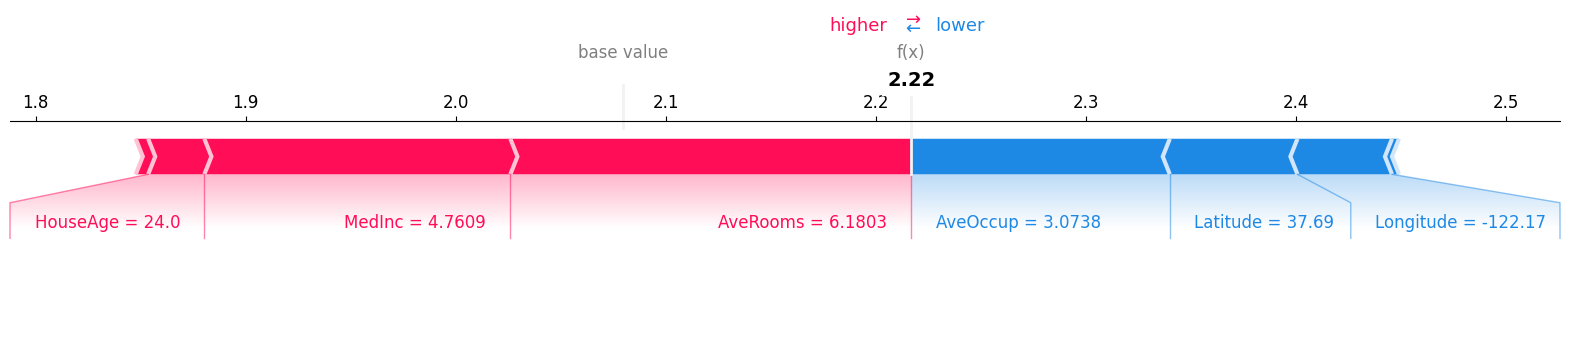

In [13]:
shap.plots.force(shap_values[observation_of_interest], matplotlib=True, show=True)

The average prediction for all houses in the dataset is shown as the *base value*, which is about 2.08. The prediction for this specific census block is 2.22, labeled as *f(x)*.

Features that increase the prediction relative to the base value are shown in red, while features that decrease the prediction are shown in blue. In this example, features such as `HouseAge`, `MedInc`, and `AveRooms` push the predicted house price upward, whereas `AveOccup`, `Latitude`, and `Longitude` decrease the prediction. The width of each arrow reflects the magnitude of the corresponding SHAP value, i.e. how strongly the feature contributes to the prediction. All feature contributions together add up to the difference between the base value and the final prediction. The feature names together with their corresponding feature values are displayed below the arrows.

You can find more advanced use cases for force plots [here](https://shap.readthedocs.io/en/latest/example_notebooks/api_examples/plots/decision_plot.html).

#### Waterfall Plot

Another way to visualize explanations for individual predictions is the waterfall plot. Similar to the force plot, it shows how each feature contributes to moving the prediction away from the average model prediction toward the final output.

The plot starts with the *base value* and then sequentially adds the contribution of each feature. Features increasing the prediction are shown in red, while features decreasing the prediction are shown in blue. In contrast to the force plot, the waterfall plot displays the feature contributions explicitly as numerical values and orders them by their magnitude, making it easier to interpret the most influential features for a prediction.

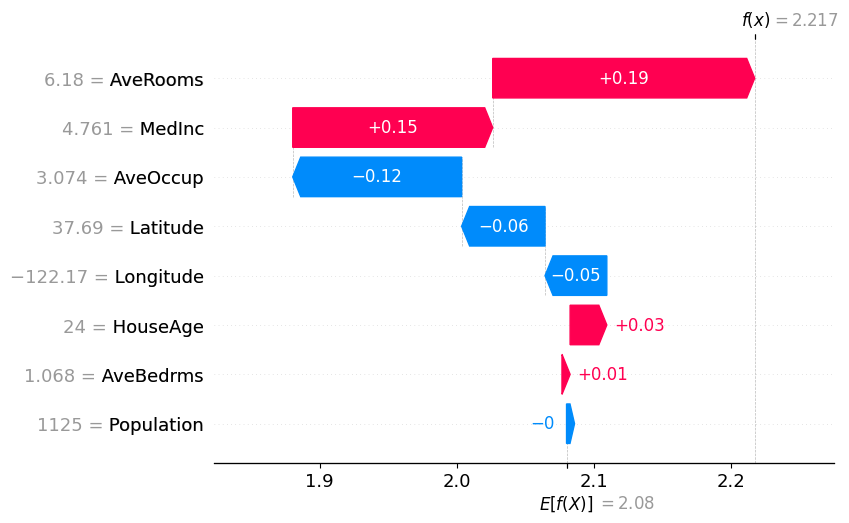

In [14]:
# get base_value as int (not list of int)
shap.plots.waterfall(shap_values[observation_of_interest])

The waterfall plot starts with the expected model output, shown at the bottom as (E[f(X)] = 2.08), and then sequentially adds the contribution of each feature until the final prediction (f(x) = 2.217) is reached. Features shown in red increase the predicted house price, while features shown in blue decrease it. The numbers displayed inside the bars correspond to the SHAP values, i.e. the contribution of each feature to the prediction relative to the average model output. The gray text on the left shows the actual feature values for this sample.

*Note: SHAP values are sometimes misinterpreted. A SHAP value does not represent the effect of removing a feature from model training. Instead, it estimates how much a feature contributes to moving the prediction away from the average prediction, given the current combination of feature values.*

### Global Explanations with SHAP

The local explanation plots are great for looking at the model's predictions with granularity. But what if we want a simple summary of how important each feature is in making predictions for the entire data set - something like *feature importance*?

While local SHAP explanations help us understand individual predictions, SHAP can also be used to analyze the overall behavior of a model across the complete dataset. By aggregating SHAP values over many samples, we can identify which features are most important globally and how different feature values influence the model predictions on average.

#### Global Bar Plots

SHAP provides global feature importance plots by aggregating the SHAP values over all samples. The most common approach is to compute the **mean absolute SHAP value** for each feature. Features with larger mean absolute SHAP values have a stronger overall influence on the model predictions and are therefore considered more important globally. Unlike local explanations, these plots summarize the average impact of each feature across the entire dataset.

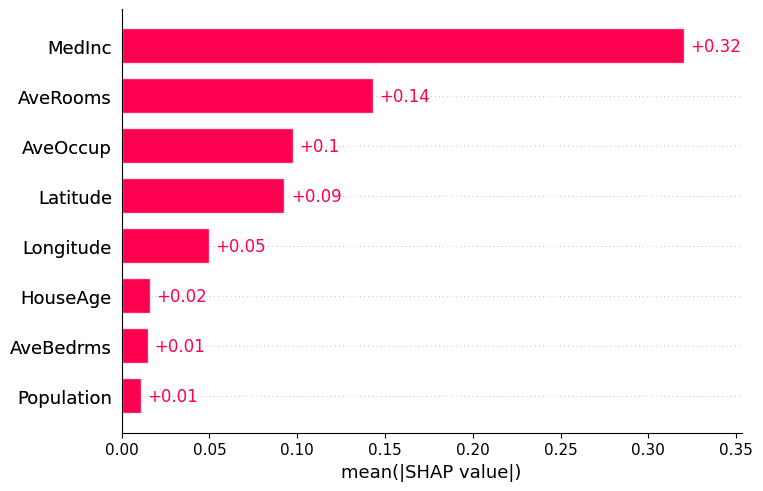

In [15]:
shap.plots.bar(shap_values)

The numbers beside each feature correspond to the **mean absolute SHAP values**, which are used as a measure of global feature importance. They are calculated by taking the absolute SHAP values for a feature across all samples and averaging them. Features with larger mean absolute SHAP values therefore have a stronger overall influence on the model predictions.

In this example, `MedInc` is by far the most important feature with an average absolute SHAP value of about 0.32, indicating that median income has the strongest overall effect on predicted house prices. `AveRooms`, `AveOccup`, and `Latitude` also contribute substantially to the model predictions, while features such as `AveBedrms` and `Population` have only a small overall influence.

Importantly, these global feature importances are derived directly from the local explanations of individual predictions. Each SHAP value describes the contribution of a feature for one specific sample, and the global importance is simply obtained by aggregating these local contributions across the complete dataset. This consistency between local and global explanations is one of the key strengths of SHAP and distinguishes it from many other interpretability methods.

The SHAP package also provides local bar plots, bar plots separated by cohorts or ordered by feature clustering. For more information on the different bar plots see [here](https://shap.readthedocs.io/en/latest/example_notebooks/api_examples/plots/bar.html).

#### Beeswarm and Violin Plots

The SHAP package also provides more detailed global visualizations that show not only how important features are overall, but also how individual feature values influence the model predictions across the complete dataset.

Both beeswarm and violin plots display the distribution of SHAP values for each feature over all samples. This allows us to analyze not only the magnitude of feature importance, but also the direction, spread, and variability of feature effects. In addition, the color coding of the samples indicates whether high or low feature values are associated with higher or lower model predictions.

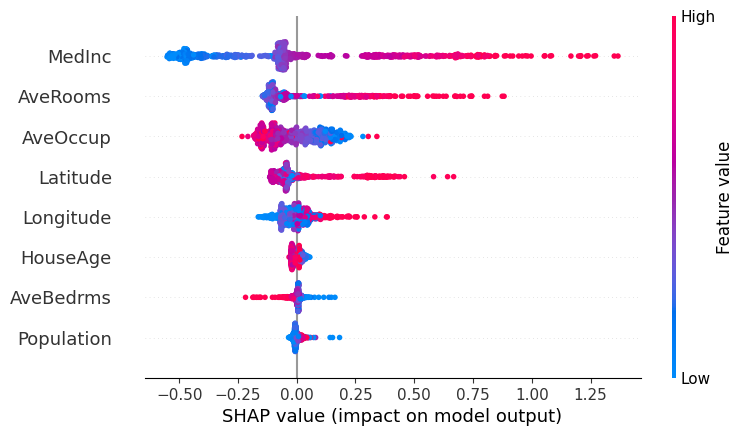

In [16]:
shap.plots.beeswarm(shap_values)

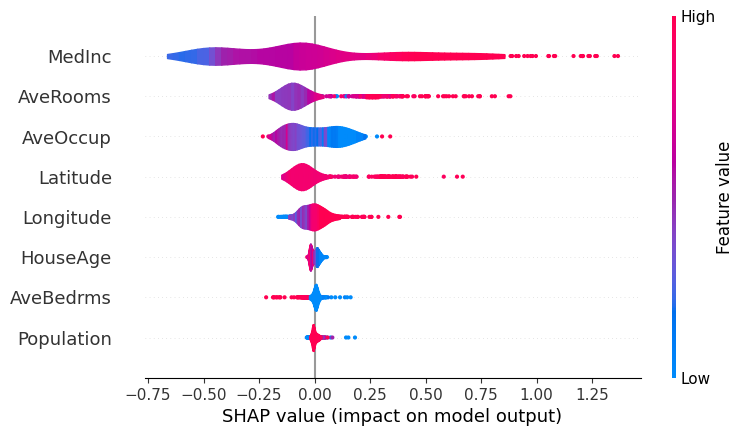

In [17]:
shap.plots.violin(shap_values)

The beeswarm plot provides an information-dense summary of how features influence the model predictions across the complete dataset. Each point represents the SHAP value of one sample for a given feature. The horizontal position indicates whether the feature increases or decreases the prediction, while the color represents the actual feature value from low (blue) to high (pink).

In this example, high values of `MedInc` strongly increase the predicted house prices, whereas low median incomes decrease the predictions. `MedInc` also shows the widest spread of SHAP values, confirming that it is the most influential feature overall. For `AveOccup`, we observe the opposite trend: low occupancy values tend to increase the predicted prices, while high occupancy values decrease them. Features such as `AveBedrms` and `Population` show only small SHAP value ranges and therefore have little influence on the predictions.

The violin plot summarizes the same information in a more compact distribution-based representation. Instead of displaying individual samples, it visualizes the density of SHAP values for each feature. Wider regions of the violin indicate ranges where many samples occur, while thinner regions correspond to less frequent SHAP values. This makes it easier to identify the spread, skewness, and variability of feature effects across the dataset.

Together, beeswarm and violin plots provide a more detailed view of global feature importance than simple bar plots, since they reveal not only how important features are overall, but also how feature values influence the direction and variability of model predictions.

#### Dependence Plots

Dependence plots show how the SHAP value of a feature changes with the actual feature value across the dataset. Each point represents one instance, where the x-axis shows the feature value and the y-axis shows the corresponding SHAP value, i.e. the contribution of that feature to the model prediction. This allows us to analyze how changes in a feature influence the model output and whether the relationship is linear, monotonic, or more complex. In addition, the points can be colored by a second, related feature. This can help reveal potential interaction effects, for example when the impact of one feature depends on the value of another feature.

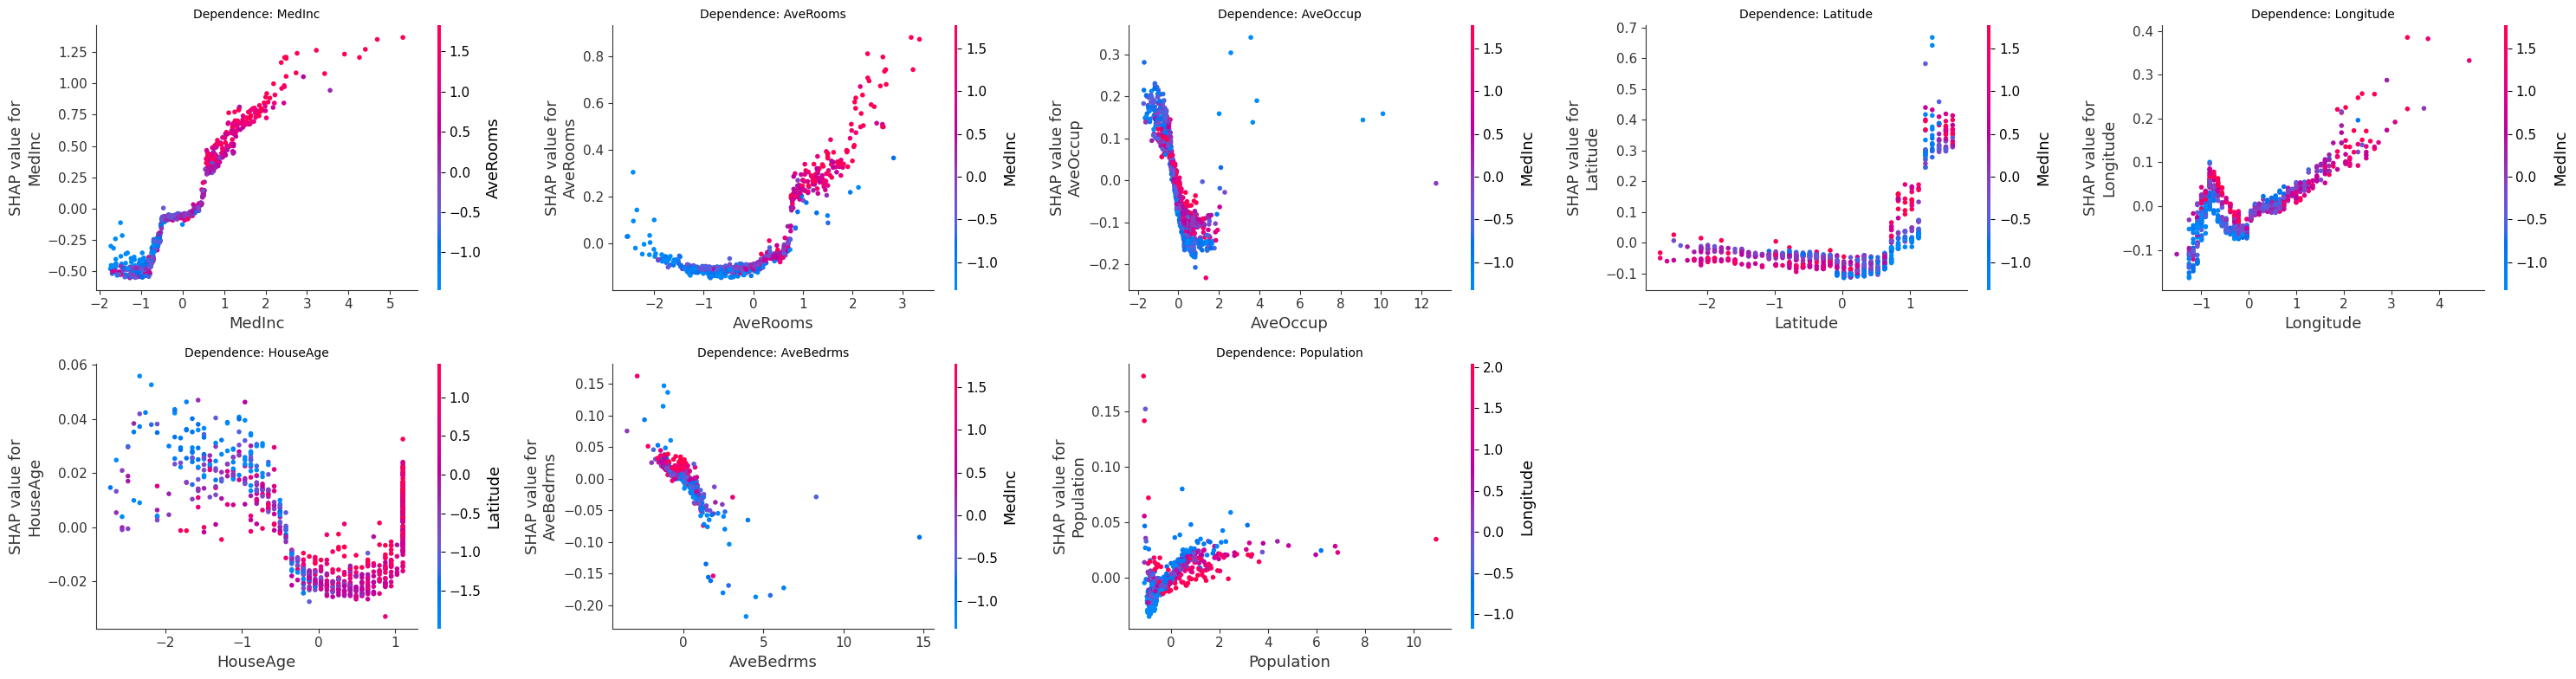

In [18]:
utils.plot_shap_dependence(shap_values, num_cols=5)

The dependence plots provide a more detailed view of how individual feature values influence the model predictions. Each point represents one sample, where the x-axis shows the feature value and the y-axis shows the corresponding SHAP value. The color indicates the value of a second, related feature and can reveal potential interaction effects.

Several clear relationships can be observed in these plots. `MedInc` shows a strong positive and almost monotonic relationship with the prediction: higher median incomes consistently increase the predicted house prices, while low incomes decrease them. A similar but weaker positive trend can be seen for `AveRooms`, where larger numbers of rooms lead to higher predictions. In contrast, `AveOccup` shows an inverse relationship. Higher occupancy values tend to reduce the predicted house prices, whereas low occupancy values increase the predictions. The `Latitude` and `Longitude` plots reveal strong non-linear geographic effects, indicating that the impact of location on house prices depends heavily on the spatial region. The plots also reveal potential feature interactions. For example, the `MedInc` dependence plot is colored by `AveRooms`, showing that high-income areas often also have larger houses. Similarly, the geographic features interact with `MedInc`, suggesting that the effect of location depends partly on the median income of the area.

Overall, the dependence plots complement the global importance plots by revealing not only which features are important, but also how feature values influence the prediction and whether these relationships are linear, non-linear, or dependent on interactions with other features.

<font color='green'>

#### Question 7: Suppose you want to explain predictions for a subgroup of patients from a specific age range. Would you necessarily use the complete training dataset as the SHAP background? What could change if you instead used only that subgroup as the background?

<font color='grey'>

#### Your Answer:

Not necessarily. The background dataset defines the reference against which the prediction is explained.

* Using the complete training dataset answers: How does this prediction differ from the model's typical prediction over the full training population?
* Using only the subgroup answers a different question: How does this prediction differ from typical predictions within this subgroup?

Changing the background can therefore change the baseline, the coalition values, and the resulting SHAP values. The appropriate background depends on the comparison that is meaningful for the analysis.

--------

<font color='green'>

#### Task: Apply SHAP to the Wine Dataset

In this exercise, you will apply **SHAP** to the trained Random Forest classifier in order to understand how different chemical properties influence the wine classification predictions.

Your task is to:

1. Create an appropriate SHAP explainer for the trained Random Forest model.
2. Compute the SHAP values for the wine dataset.
3. Visualize the global feature importance using SHAP summary plots.
4. Investigate the SHAP explanations for the individual wine classes.
5. Analyze how different chemical properties contribute positively or negatively to the prediction of each wine class.
6. Compare local explanations of individual wine samples with the global feature importance patterns.

> **Hint:** When using SHAP with classification models, the default setting of `TreeExplainer` uses `model_output="raw"`, which explains the raw model output. For classification models, this corresponds to the log-odds output. Alternatively, you can set:
>
> ```python id="h5qkfc"
> model_output="probability"
> ```
>
> to explain predictions in probability space. In this case, the SHAP values sum to the predicted class probabilities, which is often easier to interpret.

> **Hint:** For multi-class classification models, SHAP returns one SHAP value matrix and one expected value per class. Since the wine dataset contains three wine classes, you will obtain three separate SHAP explanations. The order of the SHAP outputs corresponds to the ordering of the target classes.


**The Wine dataset**

Let's use the wine quality dataset to see how XAI can be used to explain multi-class classification models. The **Wine Recognition dataset** contains 178 wine samples from three different cultivators of wine in the same region in Italy. The wine was chemically analyzed and 13 different chemical attributes like *alcohol*, *malic acid*, *flavanoids* etc were measured. Our goal is to **classify wines** and find the most predictive features.

<center><img src="https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials/blob/main/docs/source/_figures/dataset_red_wine.jpg?raw=true" width="900" /></center>

<font size=1> Source:
[Link](https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009)

In the notebook [*Gen-0-Tutorial_RandomForest_Model_Housing_Wine_Penguins.ipynb*](./Gen-0-Tutorial_RandomForest_Model_Housing_Wine_Penguins.ipynb), we explain how to do the exploratory data analysis, preprocess the data and train a Random Forest model with the given data. The focus of this notebook lies on the interpretation of the previously trained model.

In [19]:
# Load and unpack the data
with open('../models/model_rf_wine.pickle', 'rb') as handle:
    data_and_model = pickle.load(handle)
    
X_train = data_and_model[0]
X_test = data_and_model[1]
y_train = data_and_model[2]
y_test = data_and_model[3]
model_wine = data_and_model[4]

X_train.head()

# is the model performing reasonably on the training data?
print(f'Model Performance on training data: {round(model_wine.score(X_train, y_train)*100,2)} % accuracy.')

# is the model performing reasonably on the test data?
print(f'Model Performance on test data: {round(model_wine.score(X_test, y_test)*100,2)} % accuracy.')

Model Performance on training data: 100.0 % accuracy.
Model Performance on test data: 97.22 % accuracy.


As shown by the metrics above, the model achieves perfect performance on the training set while also generalizing very well to the independent test set. 

**Understanding Feature Contributions in the Wine Dataset**

We can now apply SHAP to better understand how the trained model uses the different chemical properties to distinguish between the three wine classes.

In [20]:
# run SHAP
explainer = shap.TreeExplainer(model=model_wine, data=shap.maskers.Independent(X_train, max_samples=len(X_train)), model_output="probability")
shap_values = explainer(X_train)

# get original unscaled feature values
scaler = data_and_model[5]
X_train_unscaled = scaler.inverse_transform(X_train)
X_train_unscaled = pd.DataFrame(
    scaler.inverse_transform(X_train),
    columns=X_train.columns
).round(4)
shap_values.display_data = X_train_unscaled

For our multiclass classification task, shap explainer produces three expected values, corresponding to the average probability for each class, which is essentially the class frequency in the dataset.

In [21]:
# average prediction for the dataset
ev = explainer.expected_value
pm = np.mean(model_wine.predict_proba(X_train), axis=0)

print(f'Models average prediction for our data set is for class 0: {round(pm[0],3)}, for class 1: {round(pm[1],3)}, for class 2: {round(pm[2],3)}')
print(f'Expected value for our data set is for class 0: {round(ev[0],3)}, for class 1: {round(ev[1],3)}, for class 2: {round(ev[2],3)}')

Models average prediction for our data set is for class 0: 0.32, for class 1: 0.405, for class 2: 0.275
Expected value for our data set is for class 0: 0.32, for class 1: 0.405, for class 2: 0.275


### Local Explanations

Since we have three shapley value matrices, we will have to visualize the local explanations separately for each class.

In [22]:
observation_of_interest = 5
print(f'Class for observation of interest: {y_train[observation_of_interest]}; and models prediction for the observation of interest: {model_wine.predict(X_train)[observation_of_interest]}')

Class for observation of interest: type_2; and models prediction for the observation of interest: type_2


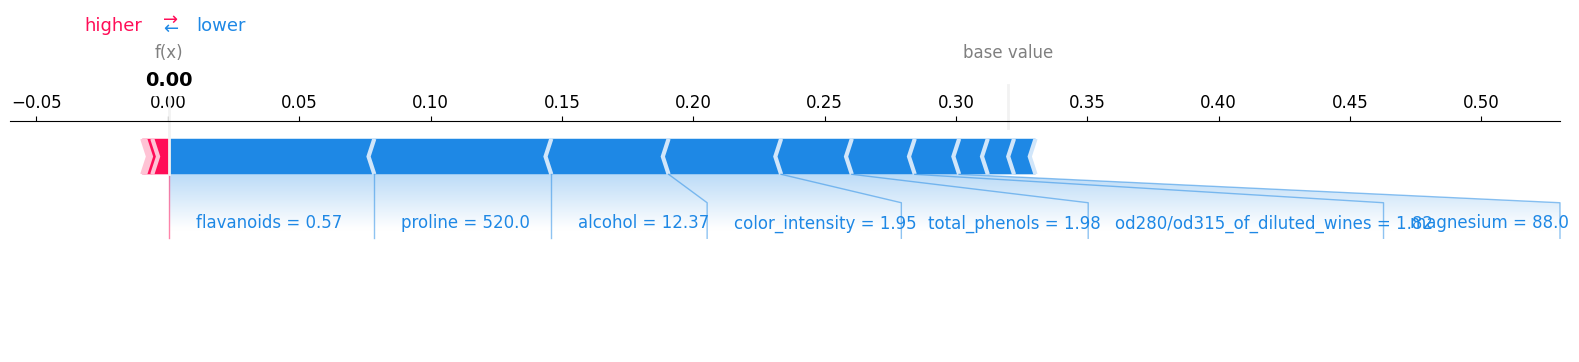

In [23]:
# force plot for class 0
target_class = 0
shap.plots.force(shap_values[observation_of_interest, :, target_class], matplotlib=True, show=True)

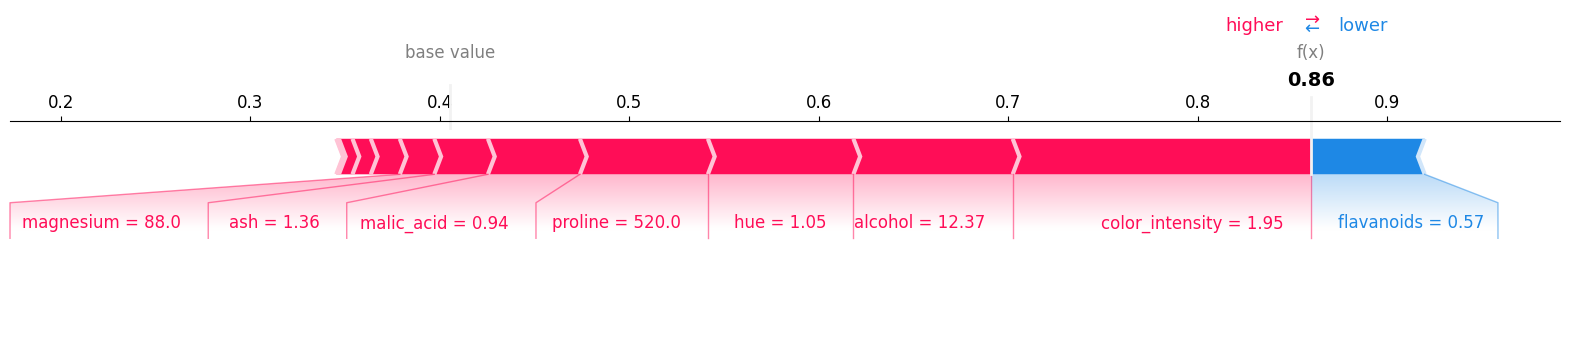

In [24]:
# force plot for class 1
target_class = 1
shap.plots.force(shap_values[observation_of_interest, :, target_class], matplotlib=True, show=True)

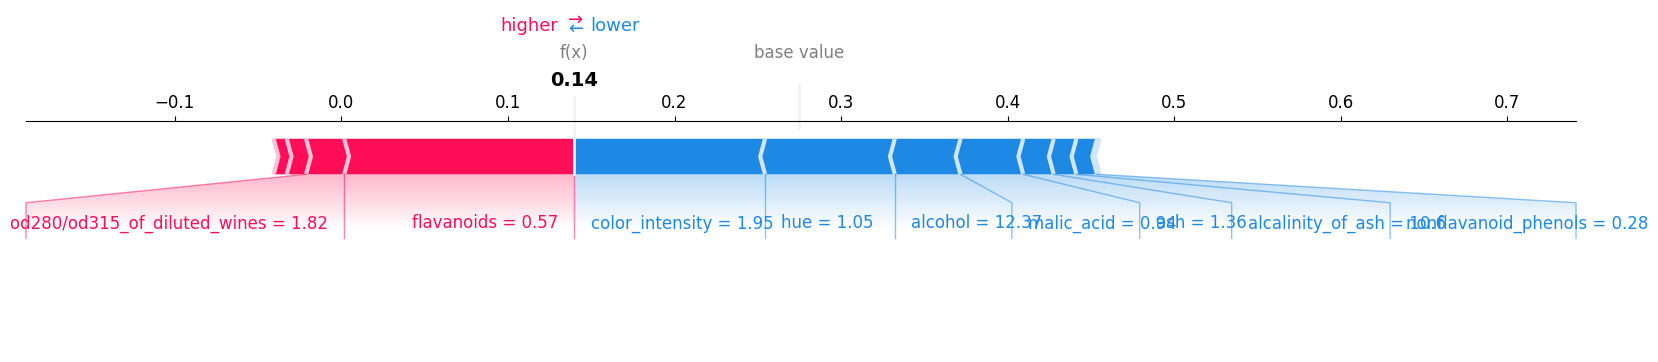

In [25]:
# force plot for class 2
target_class = 2
shap.plots.force(shap_values[observation_of_interest, :, target_class], matplotlib=True, show=True)

The average probability for each class is labeled as the *base value* in the respective plots (0.32 for type 1, 0.405, for type 2 and 0.27 for type 3). The predicted wine class probability for the observation of interest is labeled as the *f(x)*.

Comparing the three plots above, we can see that our observation of interest has a high probability of belonging to type 2 (probability = 0.87), while it has a low probability of belong to type 1 (probability = 0) or type 3 (probability = 0.13). 

Furthermore, we can see which feature contribute to a low or high class probability:
- type 1: the proline and flavanoids values highly lower the probability for this class
- type 2: the color intensity value highly increases the probability for this class
- type 3: the color intensity and hue value highly lowers the probability for this class

### Global Explanations

For the global explanations, we can visualize a bar plot that shows the average absolute SHAP values per class.

<Axes: xlabel='mean(|SHAP value|)'>

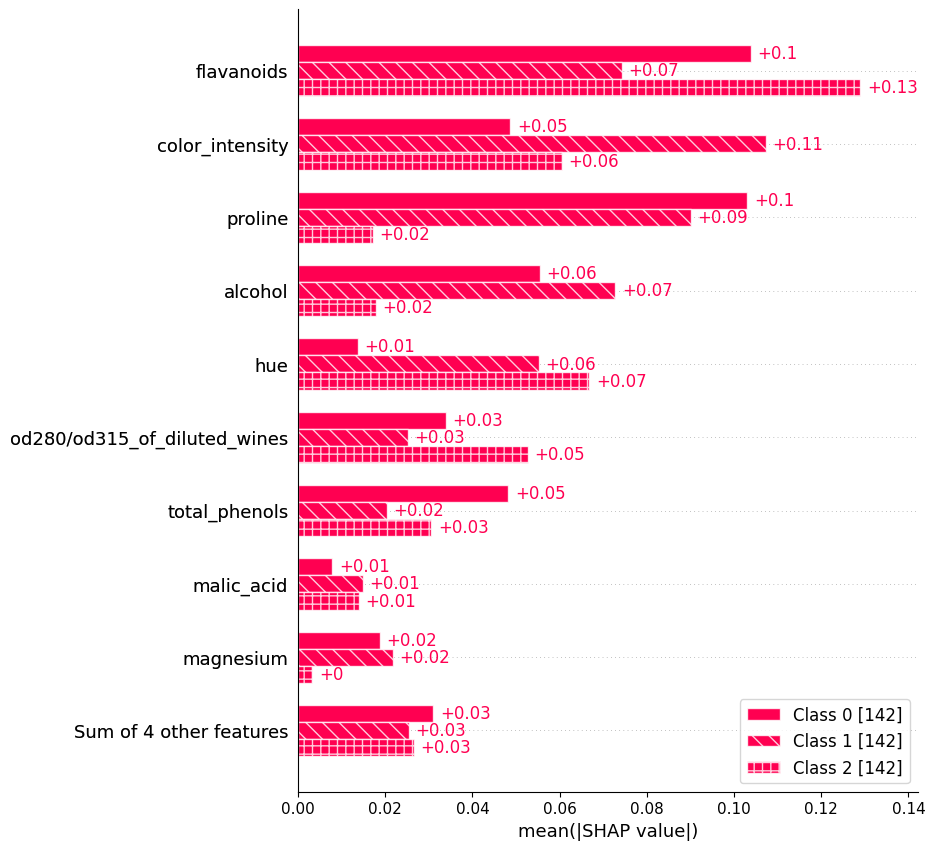

In [26]:
class_explanations = {
    "Class 0": shap_values[:, :, 0],
    "Class 1": shap_values[:, :, 1],
    "Class 2": shap_values[:, :, 2],
}

shap.plots.bar(class_explanations, show=False)

When we want to visualize the SHAP value summary as a beeswarm or violin plot, we have to do the visualization class-wise again.

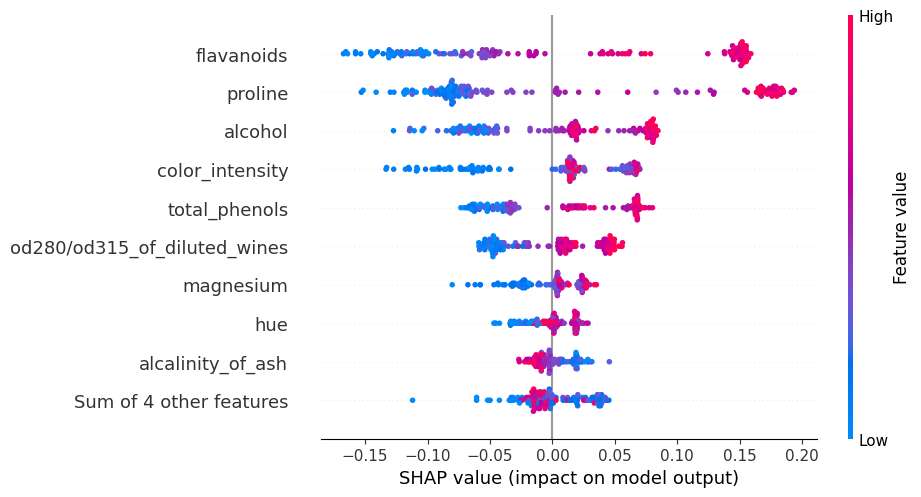

In [27]:
# summary plot for class 0
target_class = 0
shap.plots.beeswarm(shap_values[:, :, target_class], show=True)

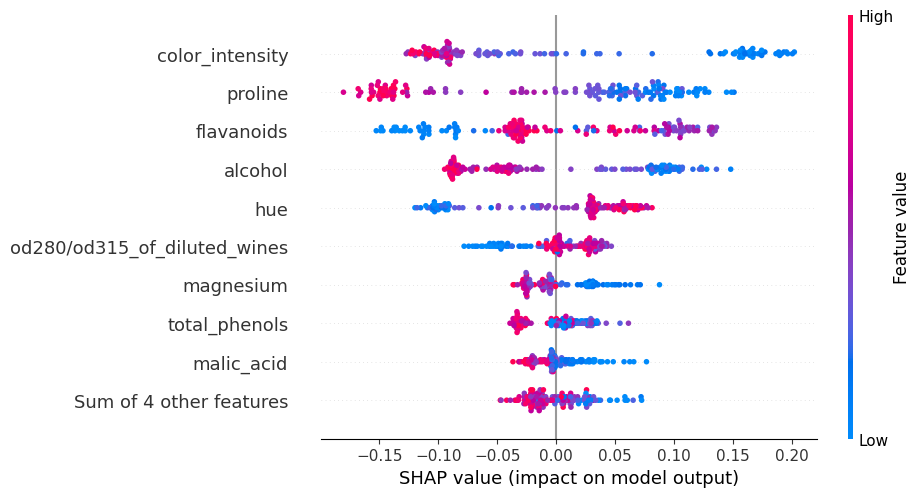

In [28]:
# summary plot for class 1
target_class = 1
shap.plots.beeswarm(shap_values[:, :, target_class], show=True)

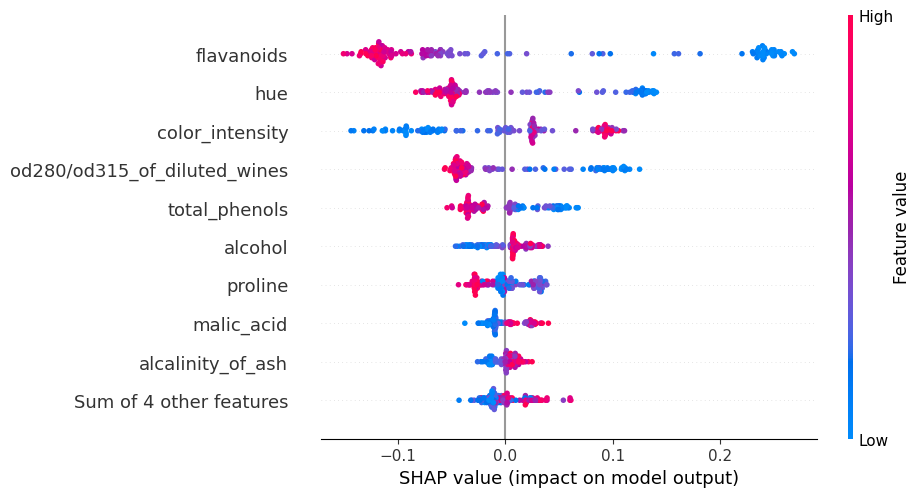

In [29]:
# summary plot for class 2
target_class = 2
shap.plots.beeswarm(shap_values[:, :, target_class], show=True)

**Conclusion**

From the plots above, we can see for instance that:

- high proline, flavanoids and alcohol values increase the probability for type 1 wines
- low color intensity, proline and alcohol values increases the probability for type 2 wines
- low flavanoids and hue but high color intensity values increase the probability for type 3 wines